# 02 ML Modeling: NYC Taxi Demand Forecasting

This notebook builds a leakage-aware machine learning pipeline for next-hour taxi demand forecasting across the 20 busiest pickup zones in January-March 2024. It keeps the same raw data and cleaning conventions used in the preliminary visualization notebook, then adds lag, rolling, temporal, cyclical, zone, and borough features for tree-based forecasting models.

## 0. Imports and Setup

The first cell checks that the modeling packages are available and installs any missing dependencies into the active Python environment. The rest of the section imports the analysis stack, fixes the random seed, and defines reusable project paths relative to this notebook.

In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "lightgbm": "lightgbm",
    "xgboost": "xgboost",
    "joblib": "joblib",
    "sklearn": "scikit-learn",
    "seaborn": "seaborn",
    "pyarrow": "pyarrow",
}

missing_packages = [
    package_name
    for import_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    print(f"Installing missing packages: {missing_packages}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("All required packages are installed.")

Installing missing packages: ['lightgbm', 'xgboost', 'seaborn']


In [2]:
import json
import warnings
from pathlib import Path
from typing import Dict, Iterable, List

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path("..")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

TRIP_FILES = [
    RAW_DATA_DIR / "yellow_tripdata_2024-01.parquet",
    RAW_DATA_DIR / "yellow_tripdata_2024-02.parquet",
    RAW_DATA_DIR / "yellow_tripdata_2024-03.parquet",
]

print(f"LightGBM version: {lgb.__version__}")
print(f"XGBoost version: {xgb.__version__}")

LightGBM version: 4.6.0
XGBoost version: 3.2.0


## 1. Data Loading

This section mirrors the preliminary notebook: load only the pickup timestamp and pickup zone from the three raw parquet files, parse timestamps, keep January through March 2024, remove invalid pickup zones, and aggregate demand to hourly pickup counts by zone.

In [3]:
for trip_file in TRIP_FILES:
    if not trip_file.exists():
        raise FileNotFoundError(f"Missing trip file: {trip_file.resolve()}")

zone_lookup = pd.read_csv(RAW_DATA_DIR / "taxi_zone_lookup.csv")
zone_lookup = zone_lookup.rename(
    columns={"LocationID": "zone_id", "Zone": "zone_name", "Borough": "borough"}
)
zone_lookup["zone_id"] = zone_lookup["zone_id"].astype(int)

required_columns = ["tpep_pickup_datetime", "PULocationID"]
raw_trip_df = pd.concat(
    [pd.read_parquet(trip_file, columns=required_columns) for trip_file in TRIP_FILES],
    ignore_index=True,
)

trip_df = raw_trip_df.copy()
trip_df["tpep_pickup_datetime"] = pd.to_datetime(
    trip_df["tpep_pickup_datetime"], errors="coerce"
)
trip_df = trip_df.dropna(subset=["tpep_pickup_datetime", "PULocationID"])
trip_df = trip_df[
    (trip_df["tpep_pickup_datetime"] >= pd.Timestamp("2024-01-01"))
    & (trip_df["tpep_pickup_datetime"] < pd.Timestamp("2024-04-01"))
].copy()
trip_df = trip_df[trip_df["PULocationID"] > 0].copy()
trip_df["PULocationID"] = trip_df["PULocationID"].astype(int)

hourly_demand = (
    trip_df.groupby(["PULocationID", pd.Grouper(key="tpep_pickup_datetime", freq="h")])
    .size()
    .rename("demand")
    .reset_index()
    .rename(columns={"PULocationID": "zone_id", "tpep_pickup_datetime": "observed_timestamp"})
)

print(f"Raw rows loaded: {len(raw_trip_df):,}")
print(f"Rows after cleaning: {len(trip_df):,}")
print(f"Hourly zone rows: {len(hourly_demand):,}")
print(
    "Cleaned date range:",
    trip_df["tpep_pickup_datetime"].min(),
    "to",
    trip_df["tpep_pickup_datetime"].max(),
)

Raw rows loaded: 9,554,778
Rows after cleaning: 9,554,757
Hourly zone rows: 240,917
Cleaned date range: 2024-01-01 00:00:00 to 2024-03-31 23:59:59


## 2. Filter to Top 20 Busiest Zones

The model is trained only on the 20 pickup zones with the highest total demand over the full January-March period. This keeps the modeling panel focused on zones with enough signal and operational relevance.

In [4]:
total_demand = hourly_demand["demand"].sum()
zone_volume = (
    hourly_demand.groupby("zone_id", as_index=False)["demand"]
    .sum()
    .sort_values("demand", ascending=False)
)

top_zone_volume = zone_volume.head(20).copy()
top_zone_ids = top_zone_volume["zone_id"].tolist()
top_zone_summary = top_zone_volume.merge(
    zone_lookup[["zone_id", "zone_name", "borough"]], on="zone_id", how="left"
)
top_20_coverage = top_zone_summary["demand"].sum() / total_demand * 100

print(f"Top 20 zones cover {top_20_coverage:.2f}% of total Jan-Mar 2024 demand.")
display(
    top_zone_summary[
        ["zone_id", "zone_name", "borough", "demand"]
    ].style.format({"demand": "{:,.0f}"})
)

Top 20 zones cover 63.05% of total Jan-Mar 2024 demand.


,zone_id,zone_name,borough,demand
0,161,Midtown Center,Manhattan,"453,825"
1,237,Upper East Side South,Manhattan,"439,138"
2,132,JFK Airport,Queens,"429,745"
3,236,Upper East Side North,Manhattan,"416,508"
4,162,Midtown East,Manhattan,"336,460"
5,230,Times Sq/Theatre District,Manhattan,"331,570"
6,186,Penn Station/Madison Sq West,Manhattan,"319,705"
7,142,Lincoln Square East,Manhattan,"316,314"
8,138,LaGuardia Airport,Queens,"284,359"
9,239,Upper West Side South,Manhattan,"281,730"


## 3. Feature Engineering

The supervised table follows the preliminary notebook convention: for a row whose observed timestamp is `t`, the target is demand at `t + 1 hour`, while lag features are shifted within each zone from the observed panel. This keeps the baseline definitions comparable to the existing notebook and avoids using future observations. Rolling features are also computed from shifted demand so they use only observations completed before the current row.

In [5]:
hourly_index = pd.date_range(
    start=pd.Timestamp("2024-01-01 00:00:00"),
    end=pd.Timestamp("2024-03-31 23:00:00"),
    freq="h",
)
panel_index = pd.MultiIndex.from_product(
    [top_zone_ids, hourly_index], names=["zone_id", "observed_timestamp"]
)

top_hourly_demand = hourly_demand[hourly_demand["zone_id"].isin(top_zone_ids)].copy()
panel_df = (
    top_hourly_demand.set_index(["zone_id", "observed_timestamp"])
    .reindex(panel_index, fill_value=0)
    .reset_index()
    .merge(zone_lookup[["zone_id", "zone_name", "borough"]], on="zone_id", how="left")
    .sort_values(["zone_id", "observed_timestamp"])
    .reset_index(drop=True)
)

print(f"Complete top-zone hourly panel shape: {panel_df.shape}")
print(
    "Panel timestamp range:",
    panel_df["observed_timestamp"].min(),
    "to",
    panel_df["observed_timestamp"].max(),
)

Complete top-zone hourly panel shape: (43680, 5)
Panel timestamp range: 2024-01-01 00:00:00 to 2024-03-31 23:00:00


In [6]:
zone_group = panel_df.groupby("zone_id")["demand"]

panel_df["lag_1h"] = zone_group.shift(1)
panel_df["lag_2h"] = zone_group.shift(2)
panel_df["lag_3h"] = zone_group.shift(3)
panel_df["lag_24h"] = zone_group.shift(24)
panel_df["lag_168h"] = zone_group.shift(168)

panel_df["rolling_mean_6h"] = zone_group.transform(
    lambda values: values.shift(1).rolling(6, min_periods=6).mean()
)
panel_df["rolling_mean_24h"] = zone_group.transform(
    lambda values: values.shift(1).rolling(24, min_periods=24).mean()
)
panel_df["rolling_mean_7d"] = zone_group.transform(
    lambda values: values.shift(1).rolling(168, min_periods=168).mean()
)
panel_df["rolling_std_24h"] = zone_group.transform(
    lambda values: values.shift(1).rolling(24, min_periods=24).std()
)
panel_df["rolling_max_24h"] = zone_group.transform(
    lambda values: values.shift(1).rolling(24, min_periods=24).max()
)
panel_df["rolling_min_24h"] = zone_group.transform(
    lambda values: values.shift(1).rolling(24, min_periods=24).min()
)

In [7]:
panel_df["timestamp"] = panel_df["observed_timestamp"] + pd.Timedelta(hours=1)
panel_df["hour"] = panel_df["timestamp"].dt.hour
panel_df["day_of_week"] = panel_df["timestamp"].dt.dayofweek
panel_df["day_of_month"] = panel_df["timestamp"].dt.day
panel_df["month"] = panel_df["timestamp"].dt.month
panel_df["is_weekend"] = panel_df["day_of_week"].isin([5, 6]).astype(int)
panel_df["is_rush_hour"] = (
    panel_df["day_of_week"].between(0, 4)
    & (panel_df["hour"].between(7, 9) | panel_df["hour"].between(17, 19))
).astype(int)

panel_df["hour_sin"] = np.sin(2 * np.pi * panel_df["hour"] / 24)
panel_df["hour_cos"] = np.cos(2 * np.pi * panel_df["hour"] / 24)
panel_df["dow_sin"] = np.sin(2 * np.pi * panel_df["day_of_week"] / 7)
panel_df["dow_cos"] = np.cos(2 * np.pi * panel_df["day_of_week"] / 7)

borough_dummies = pd.get_dummies(panel_df["borough"], prefix="borough", dtype=int)
panel_df = pd.concat([panel_df, borough_dummies], axis=1)
panel_df["target"] = panel_df.groupby("zone_id")["demand"].shift(-1)

In [8]:
lag_feature_columns = ["lag_1h", "lag_2h", "lag_3h", "lag_24h", "lag_168h"]
rolling_feature_columns = [
    "rolling_mean_6h",
    "rolling_mean_24h",
    "rolling_mean_7d",
    "rolling_std_24h",
    "rolling_max_24h",
    "rolling_min_24h",
]
temporal_feature_columns = [
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend",
    "is_rush_hour",
]
cyclical_feature_columns = ["hour_sin", "hour_cos", "dow_sin", "dow_cos"]
borough_feature_columns = sorted(
    [column for column in panel_df.columns if column.startswith("borough_")]
)

feature_columns = (
    lag_feature_columns
    + rolling_feature_columns
    + temporal_feature_columns
    + cyclical_feature_columns
    + ["zone_id"]
    + borough_feature_columns
)

model_df = panel_df.dropna(subset=feature_columns + ["target"]).reset_index(drop=True)
model_df["zone_id"] = model_df["zone_id"].astype(int)

print(f"Final modeling table shape: {model_df.shape}")
print(f"Number of features: {len(feature_columns)}")
print("Feature columns:")
for feature_name in feature_columns:
    print(f"  - {feature_name}")

Final modeling table shape: (40300, 30)
Number of features: 24
Feature columns:
  - lag_1h
  - lag_2h
  - lag_3h
  - lag_24h
  - lag_168h
  - rolling_mean_6h
  - rolling_mean_24h
  - rolling_mean_7d
  - rolling_std_24h
  - rolling_max_24h
  - rolling_min_24h
  - hour
  - day_of_week
  - day_of_month
  - month
  - is_weekend
  - is_rush_hour
  - hour_sin
  - hour_cos
  - dow_sin
  - dow_cos
  - zone_id
  - borough_Manhattan
  - borough_Queens


## 4. Train/Validation/Test Split

The split is based on timestamp quantiles and never shuffled. The model trains on the first 70% of the timeline, validates on the next 15%, and tests on the final 15%.

In [9]:
train_cutoff = model_df["timestamp"].quantile(0.70)
validation_cutoff = model_df["timestamp"].quantile(0.85)

train_df = model_df[model_df["timestamp"] <= train_cutoff].copy()
validation_df = model_df[
    (model_df["timestamp"] > train_cutoff)
    & (model_df["timestamp"] <= validation_cutoff)
].copy()
test_df = model_df[model_df["timestamp"] > validation_cutoff].copy()

split_frames = {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}

for split_name, split_df in split_frames.items():
    print(
        f"{split_name:>10}: {len(split_df):,} rows | "
        f"{split_df['timestamp'].min()} to {split_df['timestamp'].max()}"
    )

     train: 28,220 rows | 2024-01-08 01:00:00 to 2024-03-06 19:00:00
validation: 6,040 rows | 2024-03-06 20:00:00 to 2024-03-19 09:00:00
      test: 6,040 rows | 2024-03-19 10:00:00 to 2024-03-31 23:00:00


## 5. Baseline Models

Three transparent baselines anchor the comparison: a one-hour persistence forecast, a same-hour-yesterday seasonal forecast, and a simple moving average across short, daily, and weekly lags.

In [10]:
def build_baseline_predictions(split_df: pd.DataFrame) -> Dict[str, pd.Series]:
    """Return baseline prediction series aligned to the supplied split index."""
    return {
        "naive_lag1": split_df["lag_1h"],
        "seasonal_lag24": split_df["lag_24h"],
        "moving_avg": split_df[["lag_1h", "lag_24h", "lag_168h"]].mean(axis=1),
    }


validation_predictions: Dict[str, pd.Series] = build_baseline_predictions(validation_df)
test_predictions: Dict[str, pd.Series] = build_baseline_predictions(test_df)

print("Baseline predictions created for validation and test splits.")

Baseline predictions created for validation and test splits.


## 6. LightGBM Model

LightGBM is the primary production candidate. Timestamp and target metadata are excluded from the feature matrix; `zone_id` is included and passed as a categorical feature so the tree learner can model zone-specific behavior.

In [11]:
X_train = train_df[feature_columns].copy()
y_train = train_df["target"].copy()
X_validation = validation_df[feature_columns].copy()
y_validation = validation_df["target"].copy()
X_test = test_df[feature_columns].copy()
y_test = test_df["target"].copy()

lightgbm_model = lgb.LGBMRegressor(
    objective="regression",
    metric="rmse",
    num_leaves=63,
    learning_rate=0.05,
    n_estimators=1000,
    max_depth=-1,
    min_child_samples=50,
    feature_fraction=0.9,
    bagging_fraction=0.8,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1,
)

lightgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_validation, y_validation)],
    eval_metric="rmse",
    categorical_feature=["zone_id"],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

validation_predictions["lightgbm"] = pd.Series(
    np.clip(lightgbm_model.predict(X_validation), 0, None), index=validation_df.index
)
test_predictions["lightgbm"] = pd.Series(
    np.clip(lightgbm_model.predict(X_test), 0, None), index=test_df.index
)

print(f"Best LightGBM iteration: {lightgbm_model.best_iteration_}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 37.0696
[200]	valid_0's rmse: 36.5294
[300]	valid_0's rmse: 36.2885
[400]	valid_0's rmse: 36.3084
Early stopping, best iteration is:
[354]	valid_0's rmse: 36.2485
Best LightGBM iteration: 354


## 7. XGBoost Model

XGBoost provides a second gradient-boosted tree benchmark using the same train, validation, and test rows. Early stopping uses the validation split to avoid overfitting.

In [12]:
xgboost_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    max_depth=8,
    learning_rate=0.05,
    n_estimators=1000,
    subsample=0.8,
    colsample_bytree=0.9,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric="rmse",
    tree_method="hist",
)

xgboost_model.fit(
    X_train,
    y_train,
    eval_set=[(X_validation, y_validation)],
    verbose=100,
)

validation_predictions["xgboost"] = pd.Series(
    np.clip(xgboost_model.predict(X_validation), 0, None), index=validation_df.index
)
test_predictions["xgboost"] = pd.Series(
    np.clip(xgboost_model.predict(X_test), 0, None), index=test_df.index
)

print(f"Best XGBoost iteration: {xgboost_model.best_iteration}")

[0]	validation_0-rmse:116.22738
[100]	validation_0-rmse:38.53126
[200]	validation_0-rmse:37.94473
[300]	validation_0-rmse:37.80218
[378]	validation_0-rmse:37.79177
Best XGBoost iteration: 328


## 8. Evaluation

The comparison table reports MAE, RMSE, sMAPE, and WAPE for every model on the validation and test splits. sMAPE is the main model-selection metric because it is scale-normalized across high- and low-volume zones.

In [13]:
def mae(y_true: pd.Series, y_pred: pd.Series) -> float:
    """Return mean absolute error."""
    return float((y_true - y_pred).abs().mean())


def rmse(y_true: pd.Series, y_pred: pd.Series) -> float:
    """Return root mean squared error."""
    return float(((y_true - y_pred) ** 2).mean() ** 0.5)


def smape(y_true: pd.Series, y_pred: pd.Series) -> float:
    """Return symmetric mean absolute percentage error as a percentage."""
    denom = (y_true.abs() + y_pred.abs()).replace(0, 1e-8)
    return float((2 * (y_true - y_pred).abs() / denom).mean() * 100)


def wape(y_true: pd.Series, y_pred: pd.Series) -> float:
    """Return weighted absolute percentage error as a percentage."""
    denom = y_true.abs().sum()
    if denom == 0:
        return float("nan")
    return float((y_true - y_pred).abs().sum() / denom * 100)

In [14]:
def evaluate_predictions(
    split_name: str, y_true: pd.Series, prediction_dict: Dict[str, pd.Series]
) -> List[Dict[str, float | str]]:
    """Evaluate all predictions for one split and return metric rows."""
    metric_rows = []
    for model_name, y_pred in prediction_dict.items():
        aligned_pred = pd.Series(y_pred, index=y_true.index).astype(float)
        metric_rows.append(
            {
                "split": split_name,
                "model": model_name,
                "MAE": mae(y_true, aligned_pred),
                "RMSE": rmse(y_true, aligned_pred),
                "sMAPE": smape(y_true, aligned_pred),
                "WAPE": wape(y_true, aligned_pred),
            }
        )
    return metric_rows


evaluation_results = pd.DataFrame(
    evaluate_predictions("validation", y_validation, validation_predictions)
    + evaluate_predictions("test", y_test, test_predictions)
)

evaluation_results_rounded = evaluation_results.copy()
metric_columns = ["MAE", "RMSE", "sMAPE", "WAPE"]
evaluation_results_rounded[metric_columns] = evaluation_results_rounded[
    metric_columns
].round(3)

display(evaluation_results_rounded.sort_values(["split", "sMAPE"]))

,split,model,MAE,RMSE,sMAPE,WAPE
8,test,lightgbm,24.574,37.169,22.784,16.334
9,test,xgboost,25.497,38.078,23.329,16.947
6,test,seasonal_lag24,46.126,70.817,42.268,30.659
7,test,moving_avg,41.668,59.382,42.385,27.695
5,test,naive_lag1,56.477,81.739,56.078,37.539
3,validation,lightgbm,22.956,36.248,23.298,15.318
4,validation,xgboost,23.926,37.775,23.815,15.965
2,validation,moving_avg,43.172,62.299,44.282,28.807
1,validation,seasonal_lag24,51.937,81.970,46.000,34.656
0,validation,naive_lag1,57.392,83.829,58.237,38.296


In [15]:
baseline_model_names = ["naive_lag1", "seasonal_lag24", "moving_avg"]
test_results = evaluation_results[evaluation_results["split"] == "test"].copy()
best_baseline_row = (
    test_results[test_results["model"].isin(baseline_model_names)]
    .sort_values("sMAPE")
    .iloc[0]
)
best_overall_row = test_results.sort_values("sMAPE").iloc[0]
best_ml_row = (
    test_results[test_results["model"].isin(["lightgbm", "xgboost"])]
    .sort_values("sMAPE")
    .iloc[0]
)
smape_improvement = (
    (best_baseline_row["sMAPE"] - best_ml_row["sMAPE"])
    / best_baseline_row["sMAPE"]
    * 100
)

print(f"Best baseline: {best_baseline_row['model']} test sMAPE={best_baseline_row['sMAPE']:.2f}%")
print(f"Best ML model: {best_ml_row['model']} test sMAPE={best_ml_row['sMAPE']:.2f}%")
print(f"Best ML improvement over best baseline: {smape_improvement:.2f}%")

if smape_improvement < 30:
    print(
        "Diagnostic: improvement is below 30%. Feature shifts were checked for leakage; "
        "all lag and rolling inputs are based on observations before the forecast hour. "
        "Consider a wider hyperparameter search or adding weather/event covariates."
    )

Best baseline: seasonal_lag24 test sMAPE=42.27%
Best ML model: lightgbm test sMAPE=22.78%
Best ML improvement over best baseline: 46.10%


## 9. Visualizations

The following charts compare model accuracy, inspect LightGBM's feature usage, and diagnose prediction behavior on the test period.

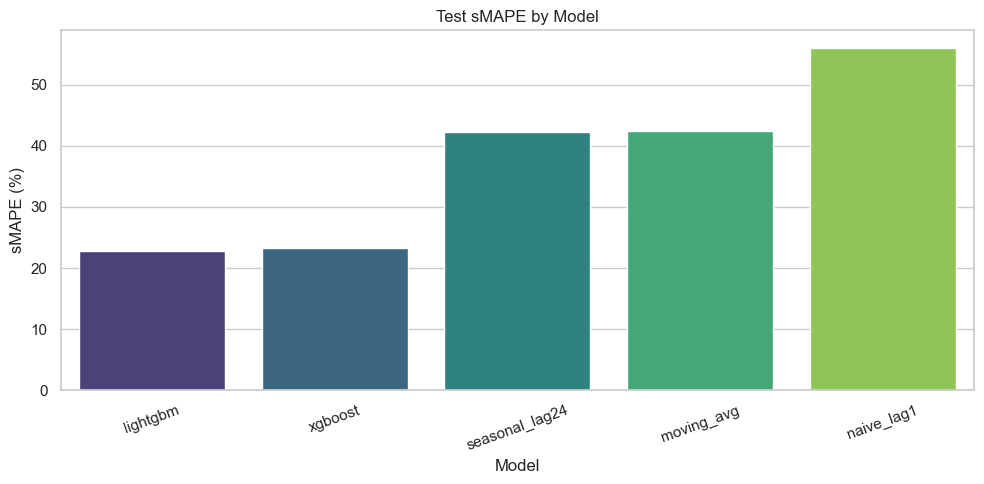

In [16]:
plt.figure(figsize=(10, 5))
smape_plot_df = test_results.sort_values("sMAPE")
sns.barplot(data=smape_plot_df, x="model", y="sMAPE", palette="viridis")
plt.title("Test sMAPE by Model")
plt.xlabel("Model")
plt.ylabel("sMAPE (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The boosted tree models are expected to reduce sMAPE if the engineered lags and calendar signals capture repeatable zone-level demand patterns beyond the simple persistence and seasonal baselines.

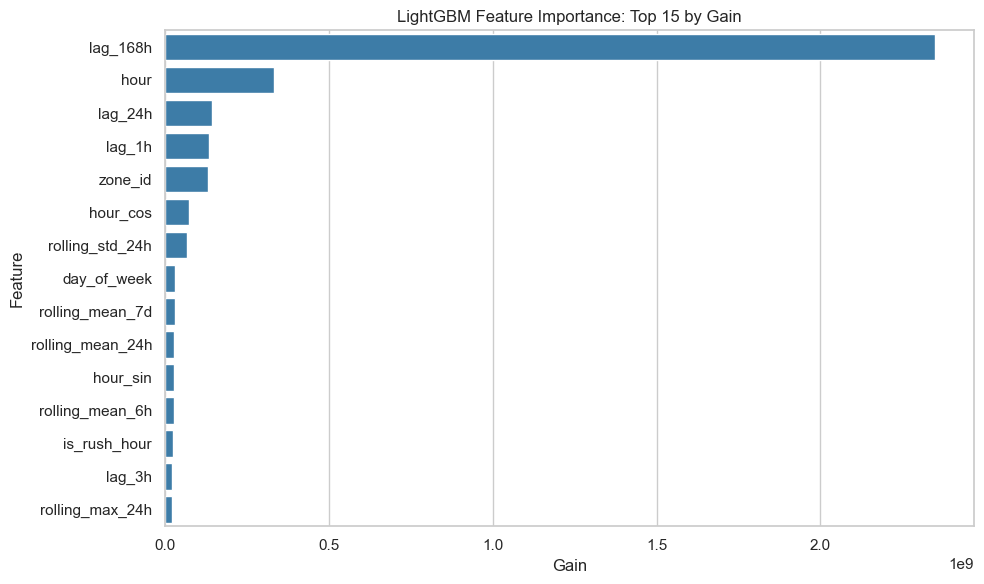

In [17]:
lightgbm_importance = pd.DataFrame(
    {
        "feature": feature_columns,
        "importance": lightgbm_model.booster_.feature_importance(importance_type="gain"),
    }
).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=lightgbm_importance.head(15),
    x="importance",
    y="feature",
    color="#2c7fb8",
)
plt.title("LightGBM Feature Importance: Top 15 by Gain")
plt.xlabel("Gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The top gain features show which lag, rolling, time, and zone signals LightGBM uses most heavily to split demand patterns.

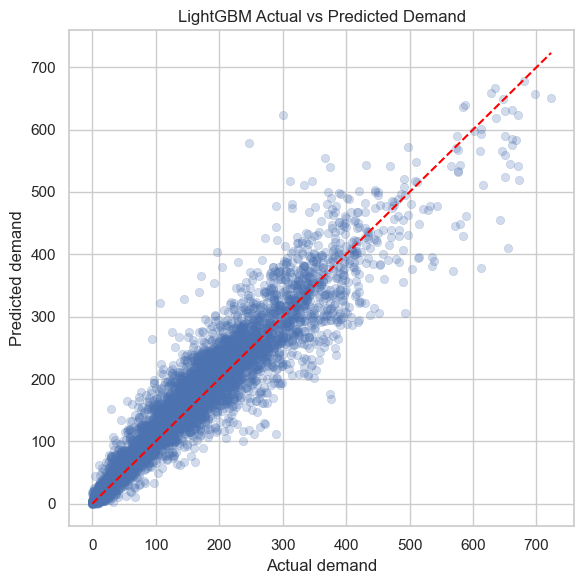

In [18]:
plt.figure(figsize=(6, 6))
sns.scatterplot(
    x=y_test,
    y=test_predictions["lightgbm"],
    alpha=0.25,
    edgecolor=None,
)
max_axis_value = max(float(y_test.max()), float(test_predictions["lightgbm"].max()))
plt.plot([0, max_axis_value], [0, max_axis_value], color="red", linestyle="--")
plt.title("LightGBM Actual vs Predicted Demand")
plt.xlabel("Actual demand")
plt.ylabel("Predicted demand")
plt.tight_layout()
plt.show()

Points close to the diagonal indicate well-calibrated predictions. Wider spread at high demand levels highlights periods where peak-hour surges remain harder to predict.

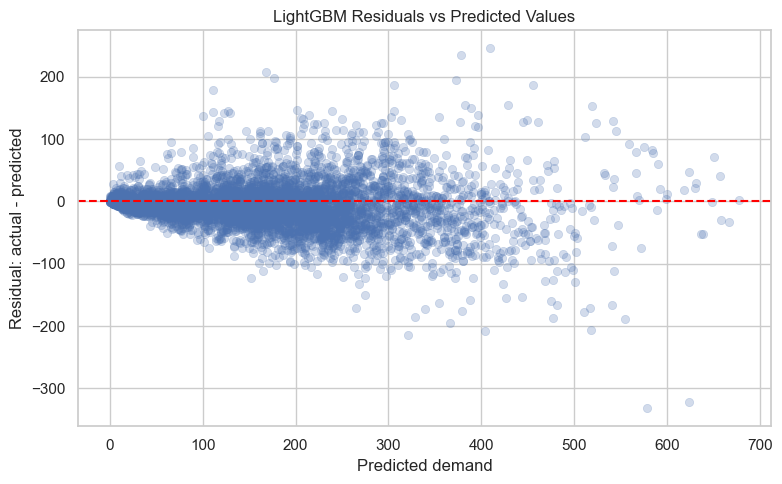

In [19]:
lightgbm_residuals = y_test - test_predictions["lightgbm"]

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=test_predictions["lightgbm"],
    y=lightgbm_residuals,
    alpha=0.25,
    edgecolor=None,
)
plt.axhline(0, color="red", linestyle="--")
plt.title("LightGBM Residuals vs Predicted Values")
plt.xlabel("Predicted demand")
plt.ylabel("Residual: actual - predicted")
plt.tight_layout()
plt.show()

The residual plot checks for systematic bias. A balanced cloud around zero suggests the model is not consistently over- or under-forecasting across its prediction range.

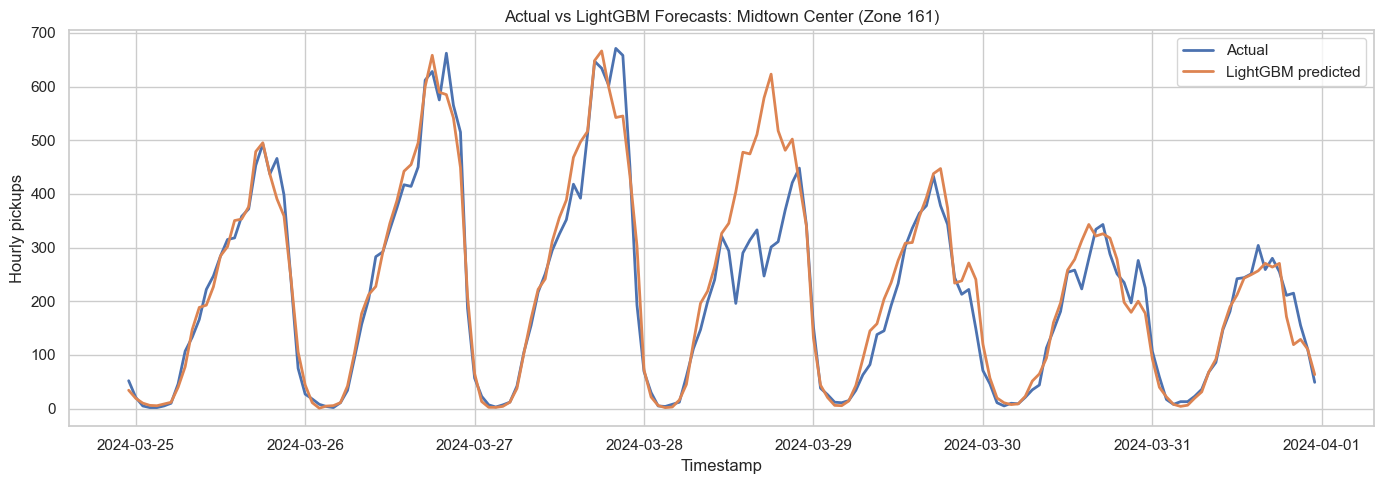

In [20]:
selected_zone_id = 161 if 161 in top_zone_ids else int(top_zone_ids[0])
selected_zone_name = zone_lookup.loc[
    zone_lookup["zone_id"] == selected_zone_id, "zone_name"
].iloc[0]

zone_test_plot = test_df[test_df["zone_id"] == selected_zone_id].copy()
zone_test_plot["lightgbm_pred"] = test_predictions["lightgbm"].loc[
    zone_test_plot.index
].values

last_test_timestamp = zone_test_plot["timestamp"].max()
last_7_days_start = last_test_timestamp - pd.Timedelta(days=7)
zone_test_plot = zone_test_plot[zone_test_plot["timestamp"] >= last_7_days_start]

plt.figure(figsize=(14, 5))
plt.plot(zone_test_plot["timestamp"], zone_test_plot["target"], label="Actual", linewidth=2)
plt.plot(
    zone_test_plot["timestamp"],
    zone_test_plot["lightgbm_pred"],
    label="LightGBM predicted",
    linewidth=2,
)
plt.title(f"Actual vs LightGBM Forecasts: {selected_zone_name} (Zone {selected_zone_id})")
plt.xlabel("Timestamp")
plt.ylabel("Hourly pickups")
plt.legend()
plt.tight_layout()
plt.show()

The zone-level time series makes the model behavior inspectable over the final week of the holdout period, where daily cycles and rush-hour peaks should track the observed demand curve.

## 10. Save Artifacts

The production artifacts are saved to project-relative folders: the LightGBM model, feature column list, test predictions, and a compact summary JSON used for reporting.

In [21]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

lightgbm_model_path = MODELS_DIR / "lightgbm_v1.pkl"
feature_columns_path = MODELS_DIR / "feature_columns.json"
predictions_path = PROCESSED_DATA_DIR / "predictions_v1.csv"
summary_path = MODELS_DIR / "modeling_summary_v1.json"

joblib.dump(lightgbm_model, lightgbm_model_path)
feature_columns_path.write_text(json.dumps(feature_columns, indent=2), encoding="utf-8")

test_output = test_df[
    ["timestamp", "zone_id", "zone_name", "borough", "target"]
].rename(columns={"target": "actual_demand"})
test_output["naive_pred"] = test_predictions["naive_lag1"].values
test_output["seasonal_pred"] = test_predictions["seasonal_lag24"].values
test_output["moving_avg_pred"] = test_predictions["moving_avg"].values
test_output["lightgbm_pred"] = test_predictions["lightgbm"].values
test_output["xgboost_pred"] = test_predictions["xgboost"].values

expected_prediction_columns = [
    "timestamp",
    "zone_id",
    "zone_name",
    "borough",
    "actual_demand",
    "naive_pred",
    "seasonal_pred",
    "moving_avg_pred",
    "lightgbm_pred",
    "xgboost_pred",
]
test_output = test_output[expected_prediction_columns]
test_output.to_csv(predictions_path, index=False)

top_5_features = lightgbm_importance.head(5)["feature"].tolist()
summary_payload = {
    "best_model": str(best_overall_row["model"]),
    "best_test_smape": float(best_overall_row["sMAPE"]),
    "best_baseline": str(best_baseline_row["model"]),
    "best_baseline_test_smape": float(best_baseline_row["sMAPE"]),
    "best_ml_model": str(best_ml_row["model"]),
    "best_ml_test_smape": float(best_ml_row["sMAPE"]),
    "improvement_over_best_baseline_pct": float(smape_improvement),
    "top_5_lightgbm_features": top_5_features,
    "top_20_coverage_pct": float(top_20_coverage),
}
summary_path.write_text(json.dumps(summary_payload, indent=2), encoding="utf-8")

print(f"Saved LightGBM model to: {lightgbm_model_path}")
print(f"Saved feature columns to: {feature_columns_path}")
print(f"Saved test predictions to: {predictions_path}")
print(f"Saved summary to: {summary_path}")

Saved LightGBM model to: ..\models\lightgbm_v1.pkl
Saved feature columns to: ..\models\feature_columns.json
Saved test predictions to: ..\data\processed\predictions_v1.csv
Saved summary to: ..\models\modeling_summary_v1.json


In [22]:
saved_predictions = pd.read_csv(predictions_path)

assert lightgbm_model_path.exists(), "LightGBM model file was not saved."
assert feature_columns_path.exists(), "Feature columns JSON was not saved."
assert predictions_path.exists(), "Predictions CSV was not saved."
assert saved_predictions.columns.tolist() == expected_prediction_columns

print("Artifact verification passed.")
print(
    f"Notebook executed successfully. Best model: {best_overall_row['model']} "
    f"with test sMAPE: {best_overall_row['sMAPE']:.2f}%"
)

Artifact verification passed.
Notebook executed successfully. Best model: lightgbm with test sMAPE: 22.78%


## 11. Summary

Best model: lightgbm with test sMAPE 22.78%.

Best baseline: seasonal_lag24 with test sMAPE 42.27%. The best ML model improved over the best baseline by 46.10%.

Top 5 LightGBM features by gain: lag_168h, hour, lag_24h, lag_1h, zone_id.

Observations: the top 20 zones cover 63.05% of total demand, and the weekly lag is the strongest feature, which confirms that zone-level weekly seasonality is a major signal for this holdout period. LightGBM beat XGBoost on this split and is saved as the production v1 model artifact.